# Customer Churn Prediction — Model Training

## Objective

The objective of this notebook is to build and evaluate machine learning models that can predict whether a telecom customer is likely to churn.

The cleaned and feature-engineered dataset prepared in the **EDA notebook** will be used as the starting point for model development.

### Model Development Workflow

1. Load the cleaned dataset
2. Perform Train-Test Split
3. Identify numerical and categorical features
4. Apply **Standard Scaling** to numerical features
5. Apply **One-Hot Encoding** to categorical features
6. Perform Feature Selection
7. Analyze Feature Importance
8. Train multiple machine learning models
9. Evaluate and compare model performance
10. Perform Hyperparameter Tuning
11. Select the best-performing model
12. Save the final model for deployment

### Evaluation

Since customer churn prediction is a classification problem, models will be evaluated using appropriate classification metrics such as:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

The final goal is to develop a reliable model that can effectively identify customers who are likely to churn.


### Importing libraries 

In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report
from sklearn.model_selection import RandomizedSearchCV

### Load the Cleaned Dataset

In [9]:
X = pd.read_csv("X_clean.csv")
y = pd.read_csv("y.csv").squeeze()

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (100000, 103)
Target Shape: (100000,)


In [12]:
X.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,months,revenue_per_call,minutes_per_call,revenue_per_month,mou_change_recent,rev_change_recent
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,52.333333,45.000000,0.0,0.333333,61,0.910787,2.559322,24.665902,188.63,0.34
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,263.333333,193.333333,0.0,5.666667,56,0.194601,1.801556,50.922857,-174.40,-11.53
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,9.000000,6.000000,0.0,0.000000,58,0.272796,3.085544,37.170862,-421.98,-17.54
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,3.666667,3.666667,0.0,0.000000,60,1.332157,2.040613,33.348333,-55.23,-2.45
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,222.333333,137.000000,0.0,0.000000,57,0.486314,3.127759,38.265263,308.62,16.31


In [13]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: churn, dtype: int64

In [14]:
print("Number of Features:", X.shape[1])
print("Number of Samples:", X.shape[0])
print("Target Classes:")
print(y.value_counts())

Number of Features: 103
Number of Samples: 100000
Target Classes:
churn
0    50438
1    49562
Name: count, dtype: int64


### Train-Test Split
Split the dataset into training and testing sets.

- **80%** of the data will be used for training.
- **20%** will be used for testing.
- `stratify=y` keeps the churn class distribution similar in both sets.
- `random_state=42` ensures reproducible results.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
                                X,
                                y,
                                test_size=0.20,
                                random_state=42,
                                stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (80000, 103)
X_test Shape: (20000, 103)
y_train Shape: (80000,)
y_test Shape: (20000,)


### Identify Numerical and Categorical Features

Separate the features into:

- **Numerical Features** — continuous or integer values.
- **Categorical Features** — text/category-based values.

This is required because numerical and categorical features need different preprocessing techniques.

In [18]:
# Identify numerical and categorical features

num_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Number of Numerical Features:", len(num_features))
print("Number of Categorical Features:", len(cat_features))

print("\nNumerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)

Number of Numerical Features: 82
Number of Categorical Features: 21

Numerical Features:
['uniqsubs', 'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models', 'truck', 'rv', 'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays', 'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'm

### Data Preprocessing

Apply different preprocessing techniques to numerical and categorical features:

- **Numerical Features:** StandardScaler
- **Categorical Features:** OneHotEncoder
- **ColumnTransformer:** Apply both transformations in a single pipeline.

The preprocessing will be fitted only on the training data to avoid data leakage.

In [22]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown = "ignore")

preprocessor = ColumnTransformer(
    transformers =[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [23]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape:", X_test_processed.shape)

X_train processed shape: (80000, 252)
X_test processed shape: (20000, 252)


### Feature Selection

Feature selection helps reduce the number of input features and keeps the most useful features for predicting customer churn.

We will use `SelectKBest` with the ANOVA F-test to select the top features based on their relationship with the target variable

In [27]:
# Select top 50 features 
selector = SelectKBest(score_func = f_classif, k =50)

X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

print("Original X_train shape:", X_train_processed.shape)
print("Selected X_train shape:", X_train_selected.shape)

print("Original X_test shape:", X_test_processed.shape)
print("Selected X_test shape:", X_test_selected.shape)

Original X_train shape: (80000, 252)
Selected X_train shape: (80000, 50)
Original X_test shape: (20000, 252)
Selected X_test shape: (20000, 50)


In [29]:
selected_mask = selector.get_support()

feature_names = preprocessor.get_feature_names_out()

selected_features = feature_names[selected_mask]

print("Number of Selected Features:", len(selected_features))
print("\nSelected Features:")
print(selected_features)

Number of Selected Features: 50

Selected Features:
['num__uniqsubs' 'num__avg3mou' 'num__avg3qty' 'num__avg6mou'
 'num__avg6qty' 'num__hnd_price' 'num__phones' 'num__models' 'num__lor'
 'num__eqpdays' 'num__mou_Mean' 'num__totmrc_Mean' 'num__change_mou'
 'num__unan_vce_Mean' 'num__plcd_vce_Mean' 'num__recv_vce_Mean'
 'num__comp_vce_Mean' 'num__custcare_Mean' 'num__ccrndmou_Mean'
 'num__cc_mou_Mean' 'num__inonemin_Mean' 'num__threeway_Mean'
 'num__mou_cvce_Mean' 'num__mou_rvce_Mean' 'num__owylis_vce_Mean'
 'num__mouowylisv_Mean' 'num__iwylis_vce_Mean' 'num__mouiwylisv_Mean'
 'num__peak_vce_Mean' 'num__mou_peav_Mean' 'num__opk_vce_Mean'
 'num__mou_opkv_Mean' 'num__attempt_Mean' 'num__complete_Mean'
 'num__callwait_Mean' 'num__mou_change_recent' 'cat__crclscod_E4'
 'cat__crclscod_EA' 'cat__asl_flag_N' 'cat__asl_flag_Y' 'cat__dualband_N'
 'cat__dualband_T' 'cat__dualband_Y' 'cat__refurb_new_N'
 'cat__refurb_new_R' 'cat__hnd_webcap_Unknown' 'cat__hnd_webcap_WC'
 'cat__hnd_webcap_WCMB' 'cat


The ANOVA F-score indicates how strongly each feature is associated with the churn target.

Higher scores indicate a stronger relationship with the target.

In [30]:
# Get scores for all processed features
feature_scores = selector.scores_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Score": feature_scores
})

# Keep only selected features
feature_importance = feature_importance[
    feature_importance["Feature"].isin(selected_features)
]

# Sort by score
feature_importance = feature_importance.sort_values(
    by="Score",
    ascending=False
)

feature_importance.head(20)

,Feature,Score
27,num__eqpdays,1046.467962
17,num__hnd_price,871.065423
177,cat__hnd_webcap_WCMB,640.136892
138,cat__asl_flag_N,374.998784
139,cat__asl_flag_Y,374.998784
30,num__totmrc_Mean,369.225604
175,cat__hnd_webcap_Unknown,320.831841
80,num__mou_change_recent,313.984930
176,cat__hnd_webcap_WC,259.640125
29,num__mou_Mean,254.597778


## Train Multiple ML Models

Now that we have 50 selected features, we'll train several classification models and compare their performance.
The models used are:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

We will compare the models using Accuracy, Precision, Recall, F1-Score and ROC-AUC.

In [45]:
# Model Dictionary
Model = {
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    )
}


# Store Model Results
results = []



# Train and Evaluate Models

for i in range(len(list(Model))):

    model = list(Model.values())[i]
    model_name = list(Model.keys())[i]

    # Train Model
    model.fit(X_train_selected, y_train)

    # Make Predictions
    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)

    # Prediction Probability
    y_train_prob = model.predict_proba(X_train_selected)[:, 1]
    y_test_prob = model.predict_proba(X_test_selected)[:, 1]



    # Training Set Performance

    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_auc = roc_auc_score(y_train, y_train_prob)



    # Testing Set Performance
  
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_auc = roc_auc_score(y_test, y_test_prob)


    # Store Testing Results

    results.append({
        "Model": model_name,
        "Accuracy": model_test_accuracy,
        "Precision": model_test_precision,
        "Recall": model_test_recall,
        "F1 Score": model_test_f1,
        "ROC-AUC": model_test_auc
    })


    
    # Print Results

    print(model_name)

    print("Model performance for Training set:")

    print("Accuracy  : {:.4f}".format(model_train_accuracy))
    print("Precision : {:.4f}".format(model_train_precision))
    print("Recall    : {:.4f}".format(model_train_recall))
    print("F1 Score  : {:.4f}".format(model_train_f1))
    print("ROC-AUC   : {:.4f}".format(model_train_auc))

    print("=" * 40)

    print("Model performance for Testing set:")

    print("Accuracy  : {:.4f}".format(model_test_accuracy))
    print("Precision : {:.4f}".format(model_test_precision))
    print("Recall    : {:.4f}".format(model_test_recall))
    print("F1 Score  : {:.4f}".format(model_test_f1))
    print("ROC-AUC   : {:.4f}".format(model_test_auc))

    print("=" * 40)
    print("\n")



XGBoost
Model performance for Training set:
Accuracy  : 0.7395
Precision : 0.7361
Recall    : 0.7395
F1 Score  : 0.7378
ROC-AUC   : 0.8223
Model performance for Testing set:
Accuracy  : 0.6176
Precision : 0.6129
Recall    : 0.6199
F1 Score  : 0.6164
ROC-AUC   : 0.6660


AdaBoost
Model performance for Training set:
Accuracy  : 0.6013
Precision : 0.5963
Recall    : 0.6052
F1 Score  : 0.6007
ROC-AUC   : 0.6415
Model performance for Testing set:
Accuracy  : 0.5950
Precision : 0.5897
Recall    : 0.6015
F1 Score  : 0.5955
ROC-AUC   : 0.6375


Random Forest
Model performance for Training set:
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000
Model performance for Testing set:
Accuracy  : 0.6062
Precision : 0.6072
Recall    : 0.5822
F1 Score  : 0.5944
ROC-AUC   : 0.6535


Decision Tree
Model performance for Training set:
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000
Model performance for Testing set:


In [46]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.61760,0.612929,0.619855,0.616372,0.665957
1,AdaBoost,0.59505,0.589655,0.601493,0.595515,0.637490
2,Random Forest,0.60625,0.607154,0.582224,0.594428,0.653466
4,Logistic Regression,0.57780,0.575921,0.561743,0.568744,0.610294
3,Decision Tree,0.54510,0.540954,0.542373,0.541662,0.545076


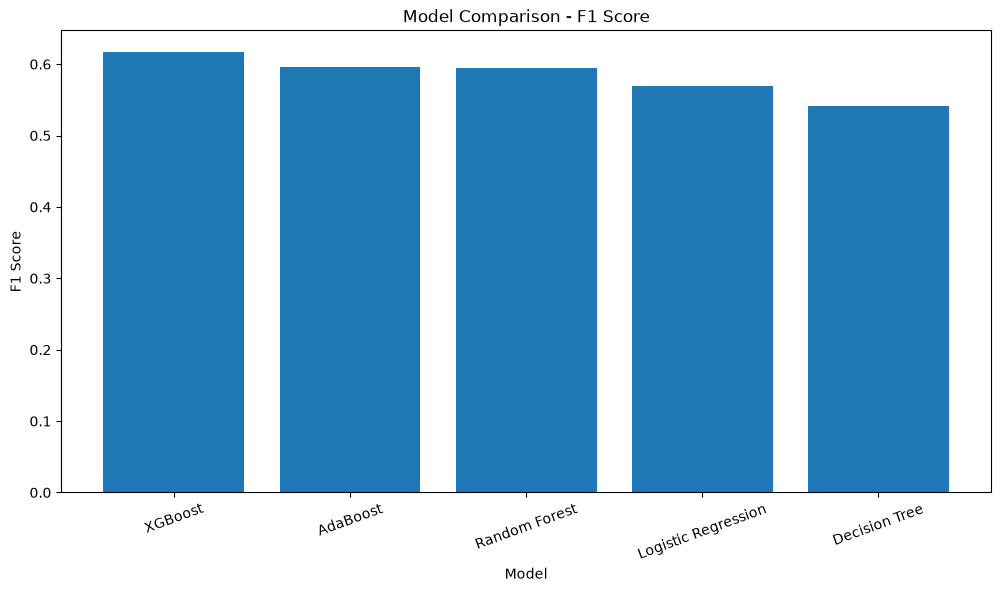

In [47]:
plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Comparison - F1 Score")
plt.xticks(rotation=20)

plt.show()

### Hyperparameter Tuning — XGBoost

XGBoost achieved the best overall performance during the initial model comparison.

In this step, we tune its hyperparameters using RandomizedSearchCV to find a better-performing configuration.

Code cell:

In [50]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_selected, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

In [51]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Best CV F1 Score:
0.6207282672022236


### Tuned XGBoost — Test Set Evaluation

The best hyperparameters obtained from RandomizedSearchCV are used to train the final XGBoost configuration.

The tuned model is evaluated on the unseen test set using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

In [53]:
best_xgb = random_search.best_estimator_

# Predictions
y_test_pred = best_xgb.predict(X_test_selected)
y_test_prob = best_xgb.predict_proba(X_test_selected)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_prob)

print("Tuned XGBoost Performance")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

Tuned XGBoost Performance
--------------------------
Accuracy : 0.6213
Precision: 0.6157654981184393
Recall   : 0.6273204196933011
F1 Score : 0.6214892553723138
ROC-AUC  : 0.6746886078857947


In [56]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.62      0.62     10088
           1       0.62      0.63      0.62      9912

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



### Compare Original vs Tuned XGBoost

In [57]:
# Original XGBoost
original_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

original_xgb.fit(X_train_selected, y_train)

original_pred = original_xgb.predict(X_test_selected)
original_prob = original_xgb.predict_proba(X_test_selected)[:, 1]

original_f1 = f1_score(y_test, original_pred)
original_auc = roc_auc_score(y_test, original_prob)

# Comparison
comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "F1 Score": [original_f1, f1],
    "ROC-AUC": [original_auc, auc]
})

comparison

,Model,F1 Score,ROC-AUC
0,Original XGBoost,0.616372,0.665957
1,Tuned XGBoost,0.621489,0.674689


In [58]:
# Final predictions
y_pred = best_xgb.predict(X_test_selected)

# Prediction probabilities
y_prob = best_xgb.predict_proba(X_test_selected)[:, 1]

print("Predicted Values:")
print(y_pred[:20])

print("\nPrediction Probabilities:")
print(y_prob[:20])

Predicted Values:
[1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 1 0 1]

Prediction Probabilities:
[0.65972096 0.6758218  0.3088833  0.39622283 0.33892485 0.3660624
 0.628675   0.5207713  0.6204211  0.2843842  0.62406796 0.7380214
 0.34691444 0.413495   0.45688418 0.72470546 0.5601464  0.54623455
 0.337455   0.52141595]


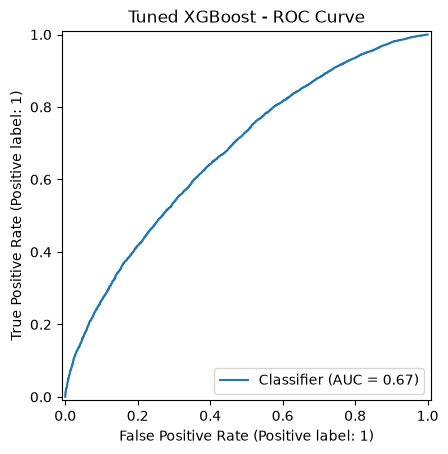

In [59]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Tuned XGBoost - ROC Curve")
plt.show()